In [1]:
import os
import re
import pdfplumber
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PATHS
# =============================================================================

PDF_PATH = r"C:\Saikat\ME\Account Statement-2.pdf"

BASE_DIR = r"C:\Saikat\ME\Bank_Track"

DATA_DIR = os.path.join(BASE_DIR, "Data")
FIGURE_DIR = os.path.join(BASE_DIR, "Figures")
REPORT_DIR = os.path.join(BASE_DIR, "Reports")

# =============================================================================
# CREATE FOLDERS
# =============================================================================

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("Folders created successfully.\n")

print(BASE_DIR)
print(DATA_DIR)
print(FIGURE_DIR)
print(REPORT_DIR)

Folders created successfully.

C:\Saikat\ME\Bank_Track
C:\Saikat\ME\Bank_Track\Data
C:\Saikat\ME\Bank_Track\Figures
C:\Saikat\ME\Bank_Track\Reports


In [20]:
from dotenv import load_dotenv
import os

load_dotenv(r"C:\Saikat\ME\.env", override=True)

PDF_PASSWORD = os.getenv("PDF_PASSWORD")

print(PDF_PASSWORD)

0530010178327


In [21]:
import os
import pdfplumber
from dotenv import load_dotenv

# =============================================================================
# PATHS
# =============================================================================

PDF_PATH = r"C:\Saikat\ME\Account Statement-2.pdf"

BASE_DIR = r"C:\Saikat\ME\Bank_Track"
DATA_DIR = os.path.join(BASE_DIR, "Data")
FIGURE_DIR = os.path.join(BASE_DIR, "Figures")
REPORT_DIR = os.path.join(BASE_DIR, "Reports")

# Create folders
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# =============================================================================
# LOAD PASSWORD
# =============================================================================

load_dotenv(r"C:\Saikat\ME\.env", override=True)

PDF_PASSWORD = os.getenv("PDF_PASSWORD")

print("Password Loaded :", PDF_PASSWORD is not None)

# =============================================================================
# READ PDF
# =============================================================================

all_text = ""

with pdfplumber.open(PDF_PATH, password=PDF_PASSWORD) as pdf:

    print(f"\nTotal Pages : {len(pdf.pages)}")

    for page in pdf.pages:

        text = page.extract_text()

        if text:
            all_text += text + "\n"

print("\nPDF Loaded Successfully")
print(f"Characters Extracted : {len(all_text):,}")

print("\nFirst 2000 Characters:\n")
print(all_text[:2000])

Password Loaded : True

Total Pages : 46

PDF Loaded Successfully
Characters Extracted : 92,334

First 2000 Characters:

Name & Address: Branch
Branch
Account No: 0530010178327 053020
Id:
Branch
SAIKAT MAHATO MANBAZAR
Name:
AT/P.O
Customer Address: S/O; NIMAI CHARAN MAHATO VILL- Branch
MANBAZARDT
TENTLAPO+PS- PEALSOLE DIST-PURULIA Address:
PURULIA
Branch
MANBAZAR MANBAZAR
City:
WEST BENGAL - 723131 PIN Code: 723131
Branch
Mobile: XXXXXXXX6199 WEST BENGAL
State:
IFSC
Aadhar Flag : Y PUNB0053020
Code:
MICR
KYC Status: Y 723024028
Code:
KYC Due Date: 15-01-2033
Nomination Available: N
CKYC No: 50XXXXXXXXXX48
Statement Period: 01-01-2026 to 28-06-2026
Instrument
Date Amount Type Balance Remarks
No
UPI/DR/116504167129/Swiggy L/UTIB
01-01-2026 ₹251.00 DEBIT NA ₹96601.68
/swiggyupiaxb/Pa
UPI/DR/116510662459/PUSPA DE/YESB
01-01-2026 ₹50.00 DEBIT NA ₹96551.68
/q950371659ybl/U
NP20235401340
Page 1 of 46
01-01-2026 ₹115.00 DEBIT NA ₹96436.68 UPI/DR/116526198739/ANNAPURN/YESB
/paytmqr63aq9dp/
UPI/

In [22]:
# =============================================================================
# SAVE EXTRACTED TEXT
# =============================================================================

text_file = os.path.join(DATA_DIR, "Extracted_Text.txt")

with open(text_file, "w", encoding="utf-8") as f:
    f.write(all_text)

print("Text saved successfully.")
print(text_file)

Text saved successfully.
C:\Saikat\ME\Bank_Track\Data\Extracted_Text.txt


In [24]:
# =============================================================================
# READ PDF (SKIP FIRST PAGE)
# =============================================================================

all_text = ""

with pdfplumber.open(PDF_PATH, password=PDF_PASSWORD) as pdf:

    print(f"Total Pages : {len(pdf.pages)}")

    # Skip the first page
    for page_no in range(1, len(pdf.pages)):

        page = pdf.pages[page_no]

        text = page.extract_text()

        if text:
            all_text += f"\n\n========== PAGE {page_no + 1} ==========\n\n"
            all_text += text

print("Done.")
print("Characters extracted :", len(all_text))

Total Pages : 46
Done.
Characters extracted : 92980


In [26]:
# =============================================================================
# SAVE EXTRACTED TEXT TO EXCEL
# =============================================================================

lines = []

with pdfplumber.open(PDF_PATH, password=PDF_PASSWORD) as pdf:

    # Skip first page (personal information)
    for page_no in range(1, len(pdf.pages)):

        text = pdf.pages[page_no].extract_text()

        if text:

            for line_no, line in enumerate(text.split("\n"), start=1):

                lines.append({
                    "Page": page_no + 1,
                    "Line": line_no,
                    "Text": line
                })

# Create DataFrame
raw_df = pd.DataFrame(lines)

# Save
excel_path = os.path.join(DATA_DIR, "Raw_Statement_Text.xlsx")

raw_df.to_excel(excel_path, index=False)

print("Saved successfully:")
print(excel_path)

print("\nTotal Lines:", len(raw_df))

Saved successfully:
C:\Saikat\ME\Bank_Track\Data\Raw_Statement_Text.xlsx

Total Lines: 3040


In [29]:
# =============================================================================
# COMBINE ALL TABLES INTO ONE DATAFRAME
# =============================================================================

df = pd.concat(all_tables, ignore_index=True)

print(df.shape)
print(df.head())

(1043, 8)
   Page  Table           0        1       2   3          4  \
0     2      1  01-01-2026  ₹115.00   DEBIT  NA  ₹96436.68   
1     2      1  01-01-2026  ₹163.75   DEBIT  NA  ₹96272.93   
2     2      1  02-01-2026   ₹50.00   DEBIT  NA  ₹96222.93   
3     2      1  02-01-2026   ₹25.00   DEBIT  NA  ₹96197.93   
4     2      1  02-01-2026   ₹25.00  CREDIT  NA  ₹96222.93   

                                                   5  
0  UPI/DR/116526198739/ANNAPURN/YESB\n/paytmqr63a...  
1  UPI/DR/636704441519/ZOMATO/HDFC\n/payzomatohdf...  
2  UPI/DR/116534496253/RAJ KUMA/YESB\n/q210166282...  
3  UPI/DR/116535031039/MANISHA/YESB\n/q231842556y...  
4  UPI-REV/116535031039/P2M/q231842556ybl\n/sm639...  


In [32]:
# =============================================================================
# COMBINE, CLEAN & MARK DAILY SPENDS
# =============================================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Combine all extracted tables
# ---------------------------------------------------------

df = pd.concat(all_tables, ignore_index=True)

# Keep only first 8 columns (adjust if your table has extras)
df = df.iloc[:, :8]

# Rename columns
df.columns = [
    "Page",
    "Table",
    "Date",
    "Amount",
    "Type",
    "NA",
    "Balance",
    "Description"
]

# ---------------------------------------------------------
# Remove empty rows
# ---------------------------------------------------------

df = df.dropna(how="all")

# ---------------------------------------------------------
# Clean Amount
# ---------------------------------------------------------

df["Amount"] = (
    df["Amount"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

# ---------------------------------------------------------
# Clean Balance
# ---------------------------------------------------------

df["Balance"] = (
    df["Balance"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Balance"] = pd.to_numeric(df["Balance"], errors="coerce")

# ---------------------------------------------------------
# Date
# ---------------------------------------------------------

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

# ---------------------------------------------------------
# Remove invalid rows
# ---------------------------------------------------------

df = df.dropna(subset=["Date", "Amount"])

# ---------------------------------------------------------
# Month
# ---------------------------------------------------------

df["Month"] = df["Date"].dt.strftime("%B %Y")

# ---------------------------------------------------------
# Category
# ---------------------------------------------------------

if "Category" not in df.columns:
    df["Category"] = "Others"

# ---------------------------------------------------------
# DAILY SPENDS
# (Debit between ₹1 and ₹500)
# ---------------------------------------------------------

daily_mask = (
    (df["Type"].str.upper() == "DEBIT") &
    (df["Amount"].between(1, 500))
)

df.loc[daily_mask, "Category"] = "Daily Spends"

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

save_path = os.path.join(DATA_DIR, "Clean_Transactions_Uptojune.xlsx")

df.to_excel(save_path, index=False)

print(df.head())

print("\nDaily Spend Transactions :", daily_mask.sum())

print("\nSaved to:")
print(save_path)

   Page  Table       Date  Amount    Type  NA   Balance  \
0     2      1 2026-01-01  115.00   DEBIT  NA  96436.68   
1     2      1 2026-01-01  163.75   DEBIT  NA  96272.93   
2     2      1 2026-01-02   50.00   DEBIT  NA  96222.93   
3     2      1 2026-01-02   25.00   DEBIT  NA  96197.93   
4     2      1 2026-01-02   25.00  CREDIT  NA  96222.93   

                                         Description         Month  \
0  UPI/DR/116526198739/ANNAPURN/YESB\n/paytmqr63a...  January 2026   
1  UPI/DR/636704441519/ZOMATO/HDFC\n/payzomatohdf...  January 2026   
2  UPI/DR/116534496253/RAJ KUMA/YESB\n/q210166282...  January 2026   
3  UPI/DR/116535031039/MANISHA/YESB\n/q231842556y...  January 2026   
4  UPI-REV/116535031039/P2M/q231842556ybl\n/sm639...  January 2026   

       Category  
0  Daily Spends  
1  Daily Spends  
2  Daily Spends  
3  Daily Spends  
4        Others  

Daily Spend Transactions : 902

Saved to:
C:\Saikat\ME\Bank_Track\Data\Clean_Transactions_Uptojune.xlsx


In [33]:
# =============================================================================
# STEP 7 : EXTRACT MERCHANT
# =============================================================================

import re

def extract_merchant(desc):

    if pd.isna(desc):
        return "Unknown"

    desc = str(desc).replace("\n", " ")

    # ----------------------------------------------------------
    # UPI Transactions
    # Example:
    # UPI/DR/116526198739/ANNAPURN/YESB/paytm...
    # Merchant = ANNAPURN
    # ----------------------------------------------------------

    if desc.startswith("UPI/"):

        parts = desc.split("/")

        if len(parts) >= 4:
            return parts[3].strip().title()

    # ----------------------------------------------------------
    # NEFT
    # ----------------------------------------------------------

    if desc.startswith("NEFT"):

        parts = desc.split("/")

        if len(parts) >= 3:
            return parts[-1].strip().title()

    # ----------------------------------------------------------
    # ACH
    # ----------------------------------------------------------

    if desc.startswith("ACH"):

        return "ACH Payment"

    # ----------------------------------------------------------
    # ATM
    # ----------------------------------------------------------

    if "ATM" in desc.upper():

        return "ATM"

    # ----------------------------------------------------------
    # SMS Charges
    # ----------------------------------------------------------

    if "SMS CHRG" in desc.upper():

        return "SMS Charges"

    # ----------------------------------------------------------
    # Default
    # ----------------------------------------------------------

    return "Others"

# Extract merchant
df["Merchant"] = df["Description"].apply(extract_merchant)

# Preview
print(df[["Description", "Merchant"]].head(20))

# Save
save_path = os.path.join(DATA_DIR, "Clean_Transactions.xlsx")
df.to_excel(save_path, index=False)

print(f"\nSaved to:\n{save_path}")

                                          Description                Merchant
0   UPI/DR/116526198739/ANNAPURN/YESB\n/paytmqr63a...                Annapurn
1   UPI/DR/636704441519/ZOMATO/HDFC\n/payzomatohdf...                  Zomato
2   UPI/DR/116534496253/RAJ KUMA/YESB\n/q210166282...                Raj Kuma
3   UPI/DR/116535031039/MANISHA/YESB\n/q231842556y...                 Manisha
4   UPI-REV/116535031039/P2M/q231842556ybl\n/sm639...                  Others
5   UPI/DR/116535529328/VBMH01/YESB\n/provenderent...                  Vbmh01
6   UPI/DR/116544256289/HUBRAJ S/FDRL/bharatpe.\n8...                Hubraj S
7   UPI/DR/600290707198/sm639948/AIRP\n/sm639948-2...                Sm639948
8      ATM ANN.CHRG FOR CARD-8215 YEAR ENDED\n2025-26                     ATM
9   UPI/DR/116667841565/Pawan/IDFB\n/9999132998pta...                   Pawan
10                     ACH/HDFCMF 05012026 CAMS/37701             ACH Payment
11                SMS CHRG FOR:01-10-2025to31-12-2025           

In [35]:
# =============================================================================
# STEP 8 : AUTOMATIC CATEGORIZATION
# =============================================================================

def get_category(row):

    merchant = str(row["Merchant"]).upper()
    desc = str(row["Description"]).upper()

    # -------------------------------------------------------
    # Salary
    # -------------------------------------------------------
    if "BAYONE" in desc or "SALARY" in desc:
        return "Salary"

    # -------------------------------------------------------
    # Food
    # -------------------------------------------------------
    if any(x in merchant for x in [
        "ZOMATO",
        "SWIGGY",
        "ANNAPURN",
        "RESTAURANT",
        "CAFE",
        "DOMINOS",
        "PIZZA",
        "HOTEL"
    ]):
        return "Food"

    # -------------------------------------------------------
    # Grocery
    # -------------------------------------------------------
    if any(x in merchant for x in [
        "ZEPTO",
        "BLINKIT",
        "DMART",
        "BIGBASKET",
        "RELIANCE",
        "PROVENDER",
        "SMART"
    ]):
        return "Groceries"

    # -------------------------------------------------------
    # Shopping
    # -------------------------------------------------------
    if any(x in merchant for x in [
        "AMAZON",
        "MYNTRA",
        "FLIPKART",
        "MEESHO",
        "AJIO"
    ]):
        return "Shopping"

    # -------------------------------------------------------
    # Investment
    # -------------------------------------------------------
    if "HDFCMF" in desc:
        return "Investment"

    # -------------------------------------------------------
    # ATM Charges
    # -------------------------------------------------------
    if "ATM" in desc:
        return "ATM Charges"

    # -------------------------------------------------------
    # Bank Charges
    # -------------------------------------------------------
    if "SMS CHRG" in desc:
        return "Bank Charges"

    # -------------------------------------------------------
    # Income
    # -------------------------------------------------------
    if str(row["Type"]).upper() == "CREDIT":
        return "Income"

    # -------------------------------------------------------
    # Default
    # -------------------------------------------------------
    return "Others"


# =============================================================================
# APPLY CATEGORIES
# =============================================================================

df["Category"] = df.apply(get_category, axis=1)

# =============================================================================
# DAILY SPENDS RULE
# Only uncategorized debit transactions between ₹1 and ₹500
# =============================================================================

daily_mask = (
    (df["Category"] == "Others") &
    (df["Type"].str.upper() == "DEBIT") &
    (df["Amount"].between(1, 500))
)

df.loc[daily_mask, "Category"] = "Daily Spends"

# =============================================================================
# SAVE
# =============================================================================

save_path = os.path.join(DATA_DIR, "Clean_Transactions.xlsx")
df.to_excel(save_path, index=False)

# =============================================================================
# SUMMARY
# =============================================================================

print("\nCategory Counts\n")
print(df["Category"].value_counts())

print("\nDaily Spend Transactions\n")
print(
    df.loc[
        df["Category"] == "Daily Spends",
        ["Date", "Merchant", "Amount", "Category"]
    ].head(30)
)

print("\nSaved to:")
print(save_path)


Category Counts

Category
Daily Spends    740
Food             96
Others           64
Groceries        60
Shopping         16
Income           12
Salary            6
Investment        3
Bank Charges      2
ATM Charges       1
Name: count, dtype: int64

Daily Spend Transactions

         Date  Merchant  Amount      Category
2  2026-01-02  Raj Kuma    50.0  Daily Spends
3  2026-01-02   Manisha    25.0  Daily Spends
5  2026-01-02    Vbmh01    36.0  Daily Spends
6  2026-01-02  Hubraj S    10.0  Daily Spends
14 2026-01-07    Vbmh01    40.0  Daily Spends
15 2026-01-07   Avinash    26.0  Daily Spends
16 2026-01-07  Iitbomby   125.0  Daily Spends
17 2026-01-07  Puspa De    50.0  Daily Spends
20 2026-01-08   Compass    20.0  Daily Spends
21 2026-01-08  Diksha C    90.0  Daily Spends
24 2026-01-08    Others    10.0  Daily Spends
25 2026-01-08  Puspa De    50.0  Daily Spends
26 2026-01-08  Rajan Ja    10.0  Daily Spends
27 2026-01-08  Rajan Ja    10.0  Daily Spends
29 2026-01-08   Compass    58.

In [36]:
# =============================================================================
# STEP 9 : ROOM RENT RULE
# =============================================================================

# Room Rent Rule
rent_mask = (
    (df["Type"].str.upper() == "DEBIT") &
    (df["Amount"].between(10400, 15200)) &
    (df["Date"].dt.day.between(1, 7))
)

# Apply
df.loc[rent_mask, "Category"] = "Room Rent"

# =============================================================================
# SAVE
# =============================================================================

save_path = os.path.join(DATA_DIR, "Clean_Transactions.xlsx")
df.to_excel(save_path, index=False)

# =============================================================================
# VERIFY
# =============================================================================

print("\nRoom Rent Transactions")
print("-" * 70)

print(
    df.loc[
        rent_mask,
        ["Date", "Merchant", "Amount", "Category"]
    ].to_string(index=False)
)

print(f"\nTotal Room Rent Payments : {rent_mask.sum()}")

print("\nSaved to:")
print(save_path)


Room Rent Transactions
----------------------------------------------------------------------
      Date    Merchant  Amount  Category
2026-01-04       Pawan 13000.0 Room Rent
2026-01-05 ACH Payment 15000.0 Room Rent
2026-03-06       Pawan 15000.0 Room Rent
2026-04-06       Pawan 13000.0 Room Rent
2026-06-04     Sunrise 13500.0 Room Rent

Total Room Rent Payments : 5

Saved to:
C:\Saikat\ME\Bank_Track\Data\Clean_Transactions.xlsx


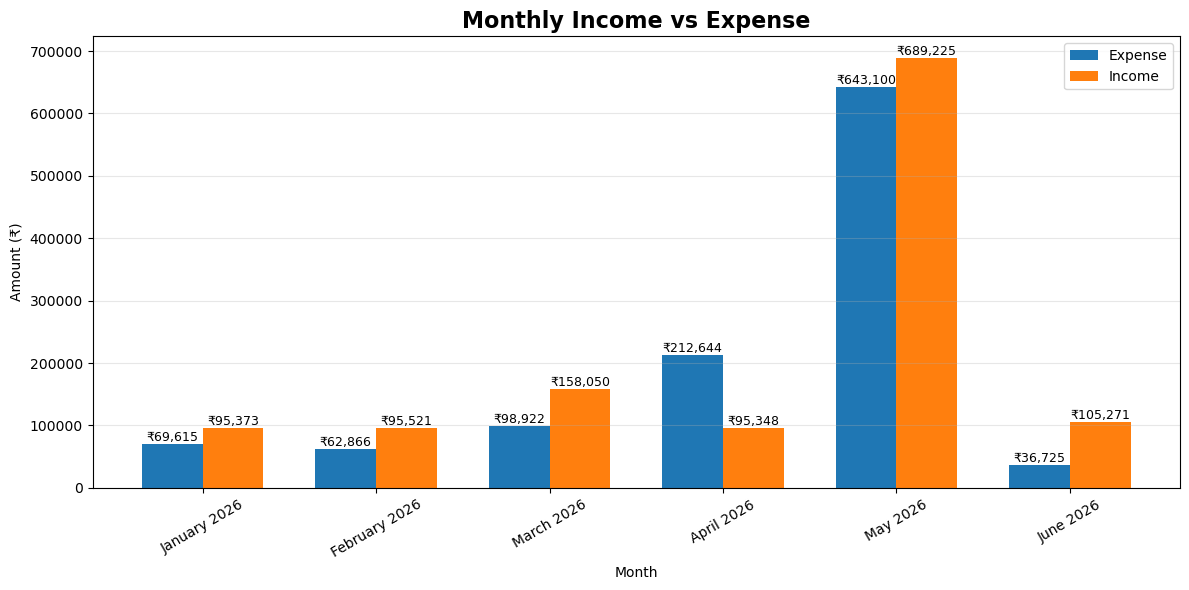

<Figure size 640x480 with 0 Axes>

In [38]:
# =============================================================================
# STEP 10 : MONTHLY INCOME VS EXPENSE
# =============================================================================

monthly_summary = (
    df.groupby(["Month", "Type"])["Amount"]
      .sum()
      .unstack(fill_value=0)
)

# Ensure both columns exist
if "DEBIT" not in monthly_summary.columns:
    monthly_summary["DEBIT"] = 0

if "CREDIT" not in monthly_summary.columns:
    monthly_summary["CREDIT"] = 0

# Order months
month_order = [
    "January 2026",
    "February 2026",
    "March 2026",
    "April 2026",
    "May 2026",
    "June 2026",
    "July 2026",
    "August 2026",
    "September 2026",
    "October 2026",
    "November 2026",
    "December 2026"
]

monthly_summary = monthly_summary.reindex(month_order).dropna(how="all")

# =============================================================================
# Plot
# =============================================================================

plt.figure(figsize=(12,6))

x = np.arange(len(monthly_summary))
width = 0.35

bars1 = plt.bar(
    x - width/2,
    monthly_summary["DEBIT"],
    width,
    label="Expense"
)

bars2 = plt.bar(
    x + width/2,
    monthly_summary["CREDIT"],
    width,
    label="Income"
)

# Value labels
for bars in [bars1, bars2]:

    for bar in bars:

        h = bar.get_height()

        if h > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                h,
                f"₹{h:,.0f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

plt.xticks(x, monthly_summary.index, rotation=30)

plt.ylabel("Amount (₹)")
plt.xlabel("Month")

plt.title(
    "Monthly Income vs Expense",
    fontsize=16,
    weight="bold"
)

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# =============================================================================
# Save
# =============================================================================

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "01_Monthly_Income_vs_Expense.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
# =============================================================================
# SAVE FIGURE
# =============================================================================

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "XX_Figure_Name.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


In [40]:
# =============================================================================
# COMPLETE CATEGORY ENGINE
# =============================================================================

def get_category(row):

    merchant = str(row["Merchant"]).upper()
    desc = str(row["Description"]).upper()
    amount = float(row["Amount"])
    ttype = str(row["Type"]).upper()
    day = row["Date"].day

    # -------------------------------------------------------
    # ROOM RENT
    # -------------------------------------------------------
    if (
        ttype == "DEBIT"
        and 10400 <= amount <= 15200
        and 1 <= day <= 7
    ):
        return "Room Rent"

    # -------------------------------------------------------
    # SALARY
    # -------------------------------------------------------
    if any(x in desc for x in [
        "BAYONE",
        "SALARY",
        "PAYROLL",
        "NEFT"
    ]) and ttype == "CREDIT":
        return "Salary"

    # -------------------------------------------------------
    # MUTUAL FUNDS
    # -------------------------------------------------------
    if any(x in desc for x in [
        "HDFCMF",
        "CAMS",
        "KFIN",
        "KFINTECH",
        "MFU",
        "SIP",
        "MFCENTRAL",
        "BSEMF",
        "COIN"
    ]):
        return "Mutual Funds"

    # -------------------------------------------------------
    # STOCKS
    # -------------------------------------------------------
    if any(x in desc for x in [
        "ZERODHA",
        "KITE",
        "UPSTOX",
        "ANGEL",
        "FYERS",
        "DHAN",
        "INDMONEY",
        "MOTILAL",
        "SHAREKHAN",
        "ICICIDIRECT"
    ]):
        return "Stocks"

    # -------------------------------------------------------
    # ETF
    # -------------------------------------------------------
    if any(x in desc for x in [
        "NIFTYBEES",
        "BANKBEES",
        "GOLDBEES",
        "JUNIORBEES"
    ]):
        return "ETF"

    # -------------------------------------------------------
    # DIGITAL GOLD
    # -------------------------------------------------------
    if any(x in desc for x in [
        "SAFEGOLD",
        "MMTC",
        "AUGMONT",
        "DIGITAL GOLD"
    ]):
        return "Digital Gold"

    # -------------------------------------------------------
    # INSURANCE
    # -------------------------------------------------------
    if any(x in desc for x in [
        "LIC",
        "SBILIFE",
        "HDFCLIFE",
        "ICICIPRU",
        "MAXLIFE",
        "TATAAIA"
    ]):
        return "Insurance"

    # -------------------------------------------------------
    # NPS / PPF
    # -------------------------------------------------------
    if any(x in desc for x in [
        "NPS",
        "NSDL",
        "PPF"
    ]):
        return "NPS / PPF"

    # -------------------------------------------------------
    # FOOD
    # -------------------------------------------------------
    if any(x in merchant for x in [
        "ZOMATO",
        "SWIGGY",
        "DOMINOS",
        "PIZZA",
        "CAFE",
        "HOTEL",
        "ANNAPURN",
        "RESTAURANT"
    ]):
        return "Food"

    # -------------------------------------------------------
    # GROCERIES
    # -------------------------------------------------------
    if any(x in merchant for x in [
        "BLINKIT",
        "ZEPTO",
        "BIGBASKET",
        "DMART",
        "RELIANCE",
        "PROVENDER",
        "SMART"
    ]):
        return "Groceries"

    # -------------------------------------------------------
    # SHOPPING
    # -------------------------------------------------------
    if any(x in merchant for x in [
        "AMAZON",
        "FLIPKART",
        "MYNTRA",
        "MEESHO",
        "AJIO"
    ]):
        return "Shopping"

    # -------------------------------------------------------
    # FUEL
    # -------------------------------------------------------
    if any(x in desc for x in [
        "HPCL",
        "BPCL",
        "IOCL",
        "PETROL",
        "FUEL"
    ]):
        return "Fuel"

    # -------------------------------------------------------
    # TRAVEL
    # -------------------------------------------------------
    if any(x in desc for x in [
        "UBER",
        "OLA",
        "IRCTC",
        "MAKEMYTRIP",
        "REDBUS"
    ]):
        return "Travel"

    # -------------------------------------------------------
    # ATM CHARGES
    # -------------------------------------------------------
    if "ATM" in desc:
        return "ATM Charges"

    # -------------------------------------------------------
    # BANK CHARGES
    # -------------------------------------------------------
    if any(x in desc for x in [
        "SMS CHRG",
        "ANNUAL CHARGE",
        "CHARGES",
        "GST"
    ]):
        return "Bank Charges"

    # -------------------------------------------------------
    # DAILY SPENDS
    # -------------------------------------------------------
    if (
        ttype == "DEBIT"
        and 1 <= amount <= 500
    ):
        return "Daily Spends"

    # -------------------------------------------------------
    # OTHER INCOME
    # -------------------------------------------------------
    if ttype == "CREDIT":
        return "Income"

    # -------------------------------------------------------
    # DEFAULT
    # -------------------------------------------------------
    return "Others"


# =============================================================================
# APPLY CATEGORY
# =============================================================================

df["Category"] = df.apply(get_category, axis=1)

# =============================================================================
# SAVE
# =============================================================================

save_path = os.path.join(DATA_DIR, "Clean_Transactions.xlsx")

df.to_excel(save_path, index=False)

print(df["Category"].value_counts())

print("\nSaved Successfully")
print(save_path)

Category
Daily Spends    736
Food             96
Groceries        60
Others           57
Shopping         16
Income           11
Salary            7
Room Rent         5
Travel            4
Stocks            3
Bank Charges      2
Mutual Funds      2
ATM Charges       1
Name: count, dtype: int64

Saved Successfully
C:\Saikat\ME\Bank_Track\Data\Clean_Transactions.xlsx


In [41]:
# =============================================================================
# CREATE INVESTMENT COLUMN
# =============================================================================

def get_investment(row):

    desc = str(row["Description"]).upper()

    # -------------------------------------------------------
    # Mutual Funds
    # -------------------------------------------------------
    if any(x in desc for x in [
        "HDFCMF",
        "CAMS",
        "KFIN",
        "KFINTECH",
        "MFU",
        "MFCENTRAL",
        "SIP",
        "COIN",
        "BSEMF"
    ]):
        return "Mutual Funds"

    # -------------------------------------------------------
    # Stocks
    # -------------------------------------------------------
    if any(x in desc for x in [
        "ZERODHA",
        "KITE",
        "UPSTOX",
        "ANGEL",
        "FYERS",
        "DHAN",
        "SHAREKHAN",
        "ICICIDIRECT",
        "MOTILAL",
        "INDMONEY"
    ]):
        return "Stocks"

    # -------------------------------------------------------
    # ETF
    # -------------------------------------------------------
    if any(x in desc for x in [
        "NIFTYBEES",
        "BANKBEES",
        "GOLDBEES",
        "JUNIORBEES"
    ]):
        return "ETF"

    # -------------------------------------------------------
    # Digital Gold
    # -------------------------------------------------------
    if any(x in desc for x in [
        "SAFEGOLD",
        "MMTC",
        "AUGMONT",
        "DIGITAL GOLD"
    ]):
        return "Digital Gold"

    # -------------------------------------------------------
    # Insurance
    # -------------------------------------------------------
    if any(x in desc for x in [
        "LIC",
        "SBILIFE",
        "HDFCLIFE",
        "ICICIPRU",
        "MAXLIFE",
        "TATAAIA"
    ]):
        return "Insurance"

    # -------------------------------------------------------
    # NPS / PPF
    # -------------------------------------------------------
    if any(x in desc for x in [
        "NPS",
        "NSDL",
        "PPF"
    ]):
        return "NPS / PPF"

    return "None"


# =============================================================================
# APPLY INVESTMENT COLUMN
# =============================================================================

df["Investment"] = df.apply(get_investment, axis=1)

# =============================================================================
# REMOVE INVESTMENTS FROM CATEGORY
# =============================================================================

investment_categories = [
    "Mutual Funds",
    "Stocks",
    "ETF",
    "Digital Gold",
    "Insurance",
    "NPS / PPF"
]

df.loc[df["Category"].isin(investment_categories), "Category"] = "Expense"

# =============================================================================
# SAVE
# =============================================================================

save_path = os.path.join(DATA_DIR, "Clean_Transactions.xlsx")
df.to_excel(save_path, index=False)

# =============================================================================
# PREVIEW
# =============================================================================

print(df[["Date", "Merchant", "Amount", "Category", "Investment"]].head(30))

print("\nInvestment Summary\n")
print(df["Investment"].value_counts())

print("\nSaved Successfully")
print(save_path)

         Date                Merchant    Amount      Category    Investment
0  2026-01-01                Annapurn    115.00          Food          None
1  2026-01-01                  Zomato    163.75          Food          None
2  2026-01-02                Raj Kuma     50.00  Daily Spends          None
3  2026-01-02                 Manisha     25.00  Daily Spends          None
4  2026-01-02                  Others     25.00        Income          None
5  2026-01-02                  Vbmh01     36.00  Daily Spends          None
6  2026-01-02                Hubraj S     10.00  Daily Spends          None
7  2026-01-02                Sm639948   5000.00        Others          None
8  2026-01-03                     ATM    295.00   ATM Charges          None
9  2026-01-04                   Pawan  13000.00     Room Rent          None
10 2026-01-05             ACH Payment  15000.00     Room Rent  Mutual Funds
11 2026-01-06             SMS Charges     17.70  Bank Charges          None
12 2026-01-0

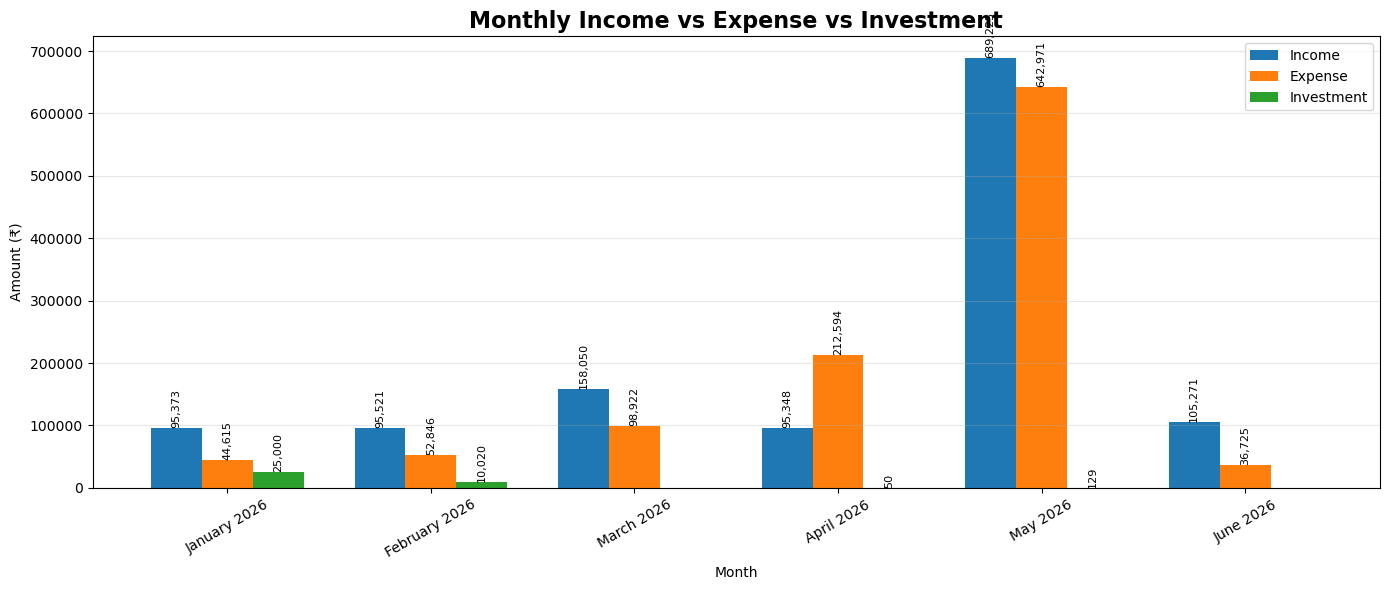

                 Income    Expense  Investment
Month                                         
January 2026    95373.0   44615.28     25000.0
February 2026   95521.0   52845.58     10020.0
March 2026     158050.0   98922.24         0.0
April 2026      95348.0  212593.77        50.0
May 2026       689225.0  642970.83       129.0
June 2026      105270.8   36724.65         0.0


In [42]:
# =============================================================================
# MONTHLY INCOME vs EXPENSE vs INVESTMENT
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Income
# ----------------------------------------------------------

income = (
    df[df["Type"] == "CREDIT"]
    .groupby("Month")["Amount"]
    .sum()
)

# ----------------------------------------------------------
# Investment
# ----------------------------------------------------------

investment = (
    df[df["Investment"] != "None"]
    .groupby("Month")["Amount"]
    .sum()
)

# ----------------------------------------------------------
# Expense (Exclude Investments)
# ----------------------------------------------------------

expense = (
    df[
        (df["Type"] == "DEBIT") &
        (df["Investment"] == "None")
    ]
    .groupby("Month")["Amount"]
    .sum()
)

# ----------------------------------------------------------
# Combine
# ----------------------------------------------------------

monthly = (
    pd.concat(
        [income, expense, investment],
        axis=1
    )
    .fillna(0)
)

monthly.columns = [
    "Income",
    "Expense",
    "Investment"
]

# ----------------------------------------------------------
# Month Order
# ----------------------------------------------------------

month_order = [
    "January 2026",
    "February 2026",
    "March 2026",
    "April 2026",
    "May 2026",
    "June 2026",
    "July 2026",
    "August 2026",
    "September 2026",
    "October 2026",
    "November 2026",
    "December 2026"
]

monthly = monthly.reindex(month_order).dropna(how="all")

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(14,6))

x = np.arange(len(monthly))
width = 0.25

bars1 = plt.bar(
    x - width,
    monthly["Income"],
    width,
    label="Income"
)

bars2 = plt.bar(
    x,
    monthly["Expense"],
    width,
    label="Expense"
)

bars3 = plt.bar(
    x + width,
    monthly["Investment"],
    width,
    label="Investment"
)

# ----------------------------------------------------------
# Value Labels
# ----------------------------------------------------------

for bars in [bars1, bars2, bars3]:

    for bar in bars:

        h = bar.get_height()

        if h > 0:

            plt.text(
                bar.get_x() + bar.get_width()/2,
                h,
                f"{h:,.0f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90
            )

plt.xticks(
    x,
    monthly.index,
    rotation=30
)

plt.ylabel("Amount (₹)")
plt.xlabel("Month")

plt.title(
    "Monthly Income vs Expense vs Investment",
    fontsize=16,
    weight="bold"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

# =============================================================================
# SAVE FIGURE
# =============================================================================

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "01_Monthly_Income_vs_Expense_vs_Investment.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

# ----------------------------------------------------------
# Print Summary
# ----------------------------------------------------------

print(monthly)

Investment
Stocks            199.0
Mutual Funds    35000.0
Name: Amount, dtype: float64


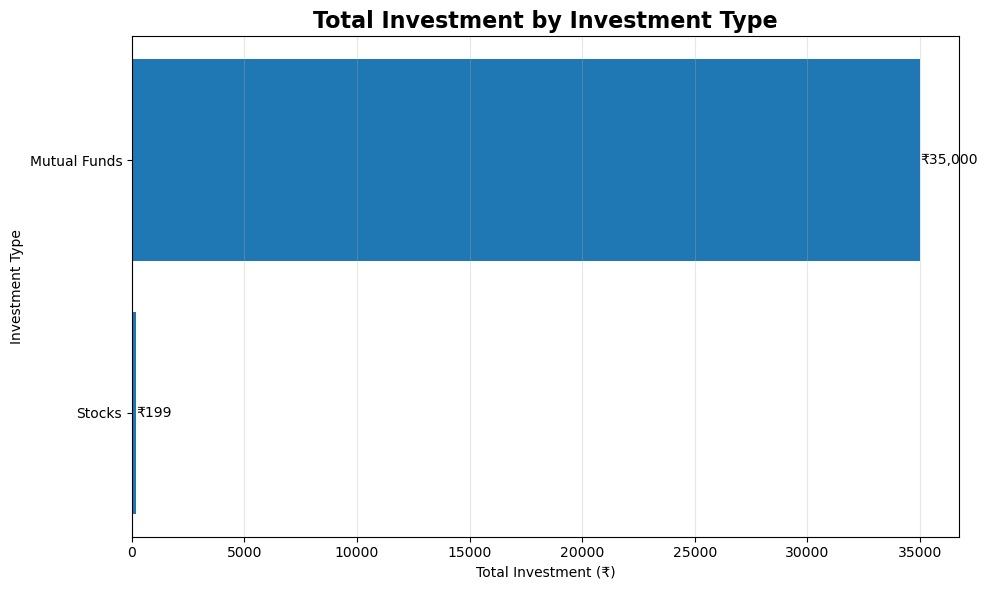

In [43]:
# =============================================================================
# INVESTMENT SUMMARY (BY INVESTMENT TYPE)
# =============================================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Keep only investment transactions
# ----------------------------------------------------------

investment_df = df[df["Investment"] != "None"].copy()

# ----------------------------------------------------------
# Sum investment amount by investment type
# ----------------------------------------------------------

investment_summary = (
    investment_df
    .groupby("Investment")["Amount"]
    .sum()
    .sort_values(ascending=True)
)

print(investment_summary)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

bars = plt.barh(
    investment_summary.index,
    investment_summary.values
)

# Value labels
for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"₹{width:,.0f}",
        va="center",
        fontsize=10
    )

plt.xlabel("Total Investment (₹)")
plt.ylabel("Investment Type")

plt.title(
    "Total Investment by Investment Type",
    fontsize=16,
    weight="bold"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

# =============================================================================
# SAVE FIGURE
# =============================================================================

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "02_Total_Investment_By_Type.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

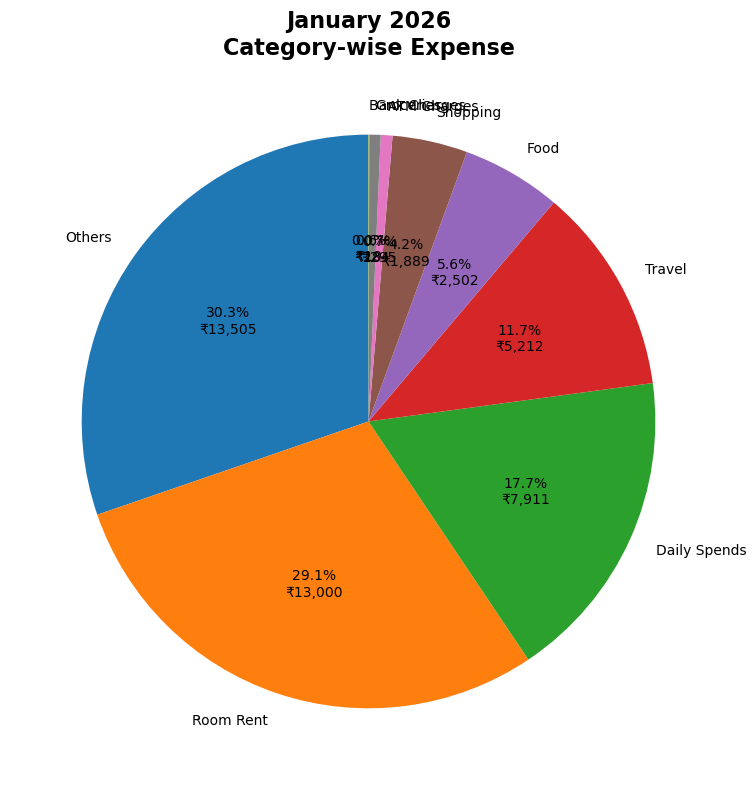

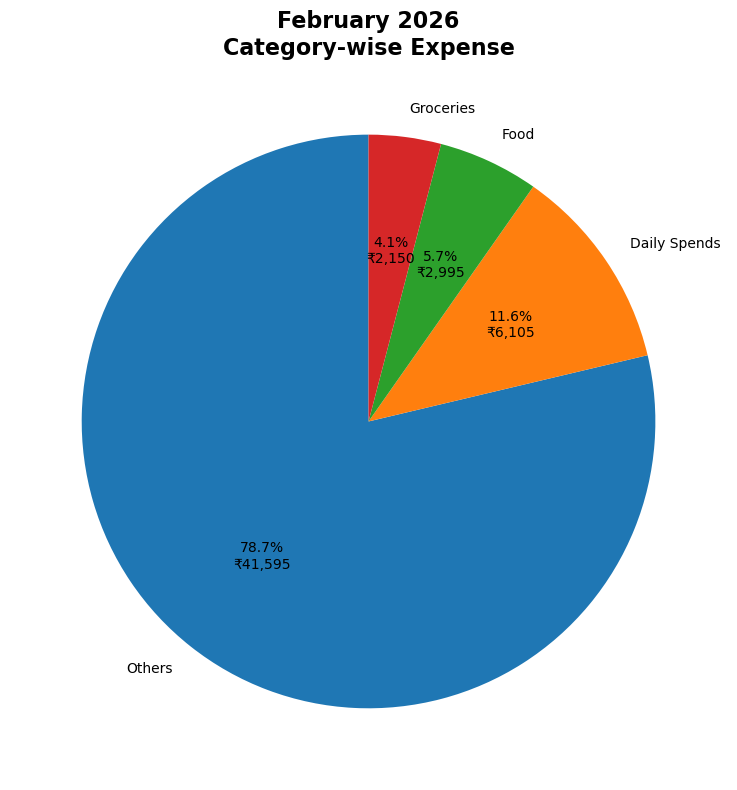

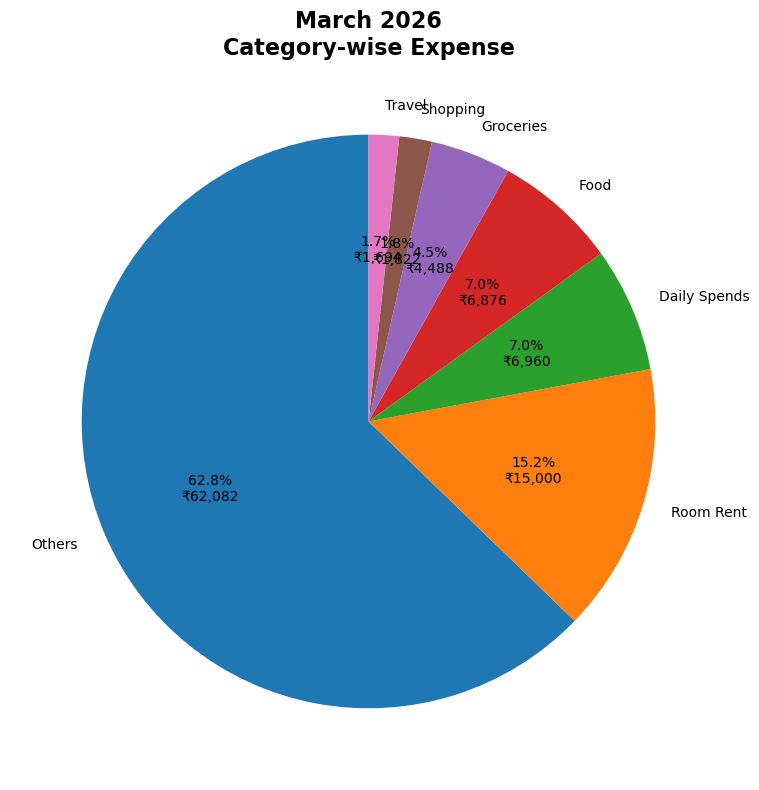

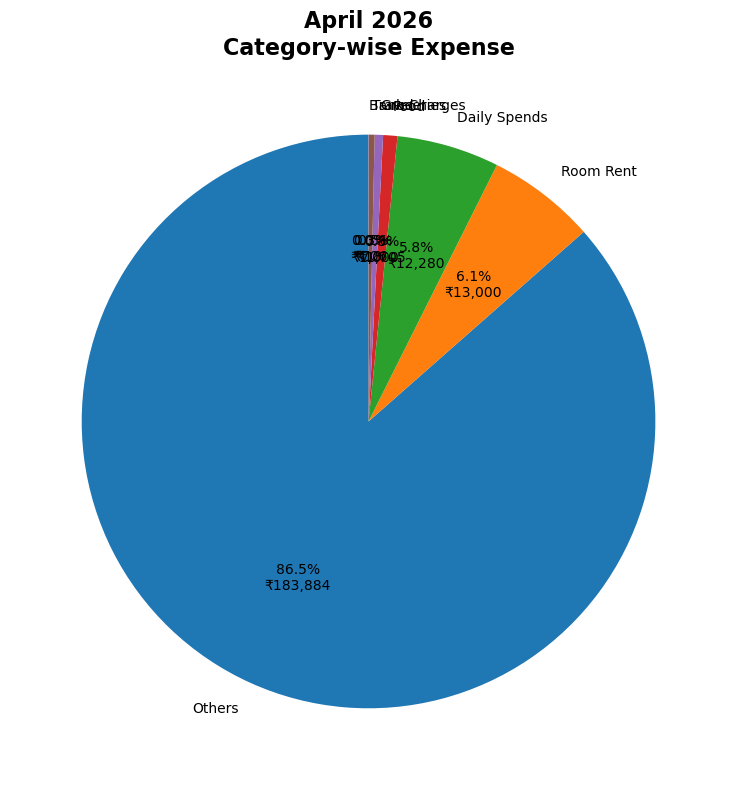

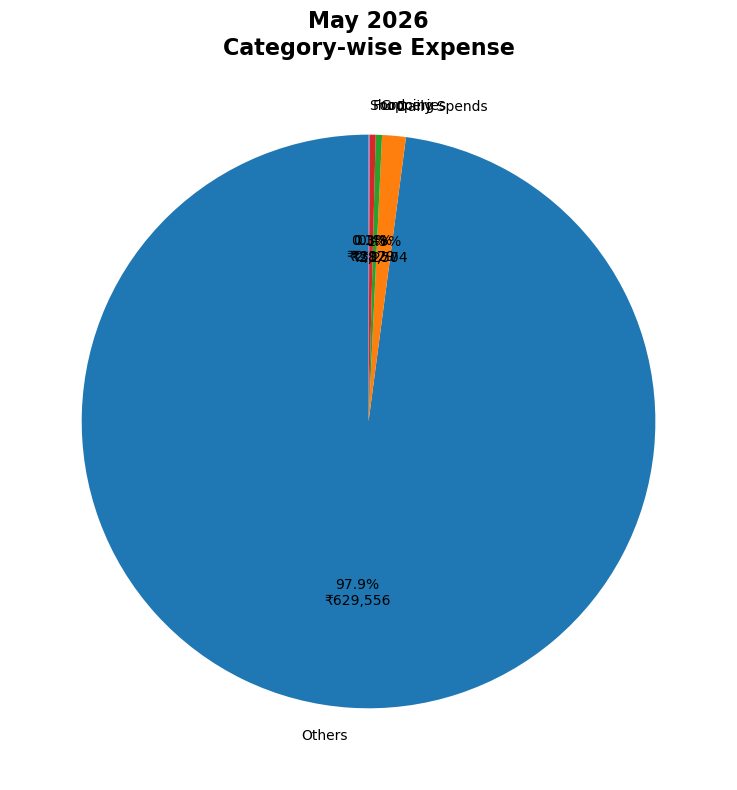

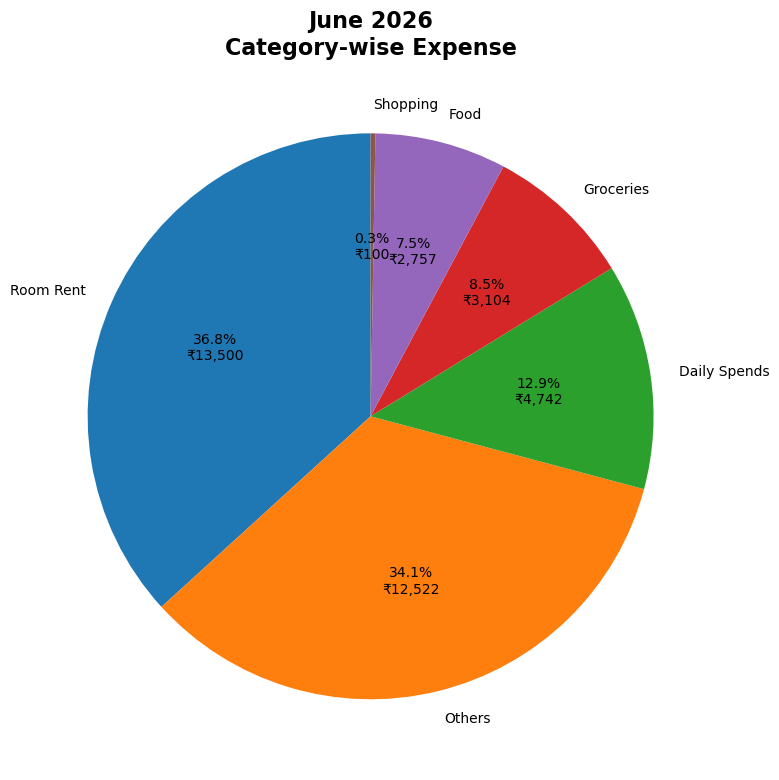

All monthly pie charts saved successfully.


In [44]:
# =============================================================================
# MONTHLY CATEGORY-WISE EXPENSE PIE CHARTS
# =============================================================================

import os
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Filter only actual expenses
# ----------------------------------------------------------

expense_df = df[
    (df["Type"] == "DEBIT") &
    (df["Investment"] == "None")
].copy()

# Remove non-expense categories if present
expense_df = expense_df[
    ~expense_df["Category"].isin([
        "Salary",
        "Income"
    ])
]

# ----------------------------------------------------------
# Month order
# ----------------------------------------------------------

month_order = [
    "January 2026",
    "February 2026",
    "March 2026",
    "April 2026",
    "May 2026",
    "June 2026",
    "July 2026",
    "August 2026",
    "September 2026",
    "October 2026",
    "November 2026",
    "December 2026"
]

# ----------------------------------------------------------
# Plot each month
# ----------------------------------------------------------

for month in month_order:

    monthly_data = expense_df[
        expense_df["Month"] == month
    ]

    if monthly_data.empty:
        continue

    category_sum = (
        monthly_data
        .groupby("Category")["Amount"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 8))

    plt.pie(
        category_sum.values,
        labels=category_sum.index,
        autopct=lambda p: f"{p:.1f}%\n₹{p/100*category_sum.sum():,.0f}",
        startangle=90
    )

    plt.title(
        f"{month}\nCategory-wise Expense",
        fontsize=16,
        weight="bold"
    )

    plt.tight_layout()

    # ======================================================
    # SAVE FIGURE
    # ======================================================

    filename = (
        "03_Category_Pie_"
        + month.replace(" ", "_")
        + ".png"
    )

    plt.savefig(
        os.path.join(FIGURE_DIR, filename),
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()
    plt.close()

print("All monthly pie charts saved successfully.")

Category
Bank Charges        35.40
ATM Charges        295.00
Shopping          4203.00
Travel            7612.35
Groceries        13296.70
Food             19014.25
Daily Spends     46572.18
Room Rent        54500.00
Others          943143.47
Name: Amount, dtype: float64


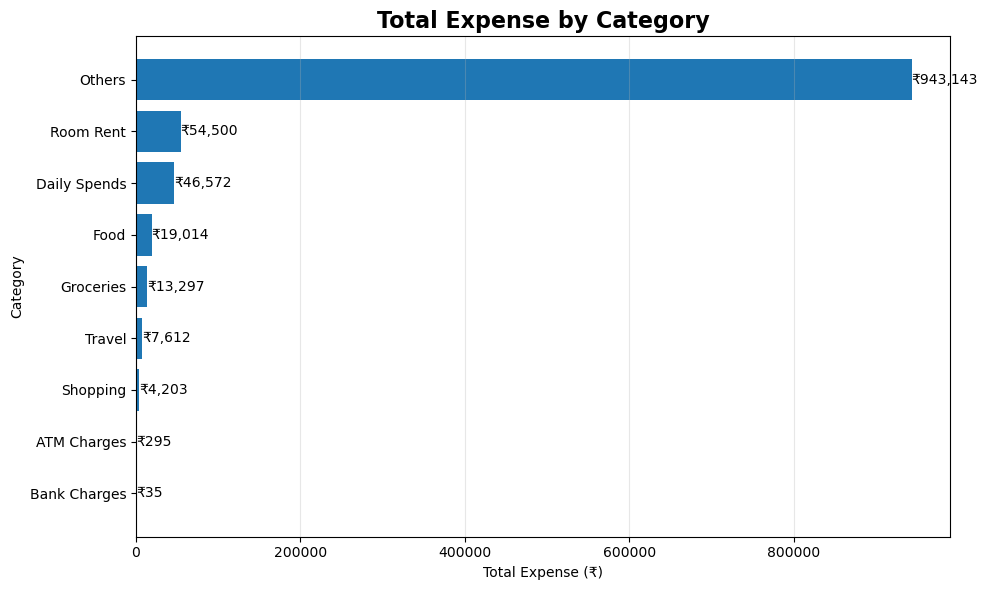

In [45]:
# =============================================================================
# TOP EXPENSE CATEGORIES
# =============================================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Filter only actual expenses
# ----------------------------------------------------------

expense_df = df[
    (df["Type"] == "DEBIT") &
    (df["Investment"] == "None")
].copy()

expense_df = expense_df[
    ~expense_df["Category"].isin([
        "Salary",
        "Income"
    ])
]

# ----------------------------------------------------------
# Sum by Category
# ----------------------------------------------------------

category_summary = (
    expense_df
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=True)
)

print(category_summary)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

bars = plt.barh(
    category_summary.index,
    category_summary.values
)

# ----------------------------------------------------------
# Value Labels
# ----------------------------------------------------------

for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"₹{width:,.0f}",
        va="center",
        fontsize=10
    )

plt.xlabel("Total Expense (₹)")
plt.ylabel("Category")

plt.title(
    "Total Expense by Category",
    fontsize=16,
    weight="bold"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

# =============================================================================
# SAVE FIGURE
# =============================================================================

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "04_Total_Expense_By_Category.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

Merchant
Zepto         3701.00
Blinkit       4054.25
Swiggy        4143.00
Zomato L      4733.34
Make My       5212.00
Saikat M      6000.00
Subhash       7200.00
Swiggy L      8118.00
Cred          9274.00
Sbi Card     12140.00
Cred Clu     14919.00
Sunrise      15500.00
Sunil Ku     25000.00
Sm639948     25000.00
Groww In     30000.00
Khandala     33000.00
Pawan        41000.00
Mutual F     50000.00
M            51500.00
Others      653758.45
Name: Amount, dtype: float64


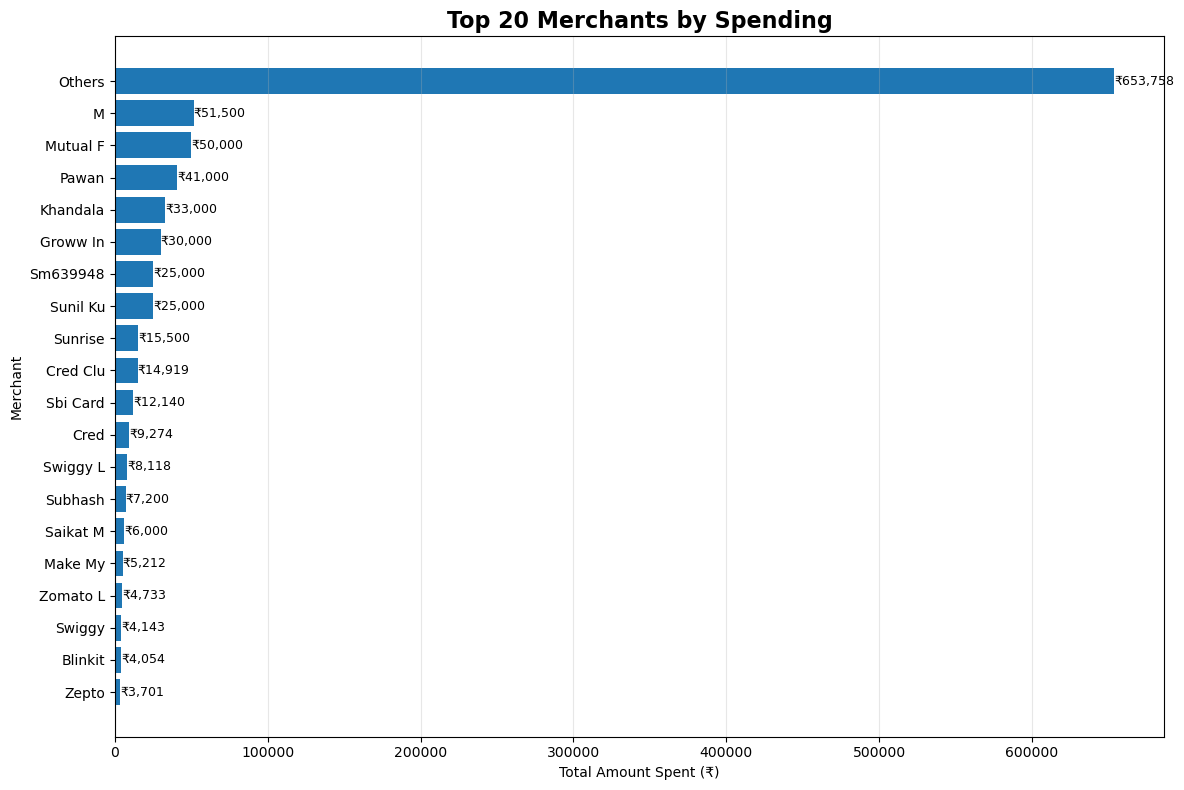

In [46]:
# =============================================================================
# TOP 20 MERCHANTS
# =============================================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Filter actual expenses
# ----------------------------------------------------------

merchant_df = df[
    (df["Type"] == "DEBIT") &
    (df["Investment"] == "None")
].copy()

merchant_df = merchant_df[
    ~merchant_df["Category"].isin([
        "Salary",
        "Income"
    ])
]

# ----------------------------------------------------------
# Sum amount by merchant
# ----------------------------------------------------------

merchant_summary = (
    merchant_df
    .groupby("Merchant")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .sort_values(ascending=True)
)

print(merchant_summary)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(12,8))

bars = plt.barh(
    merchant_summary.index,
    merchant_summary.values
)

# ----------------------------------------------------------
# Value Labels
# ----------------------------------------------------------

for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"₹{width:,.0f}",
        va="center",
        fontsize=9
    )

plt.xlabel("Total Amount Spent (₹)")
plt.ylabel("Merchant")

plt.title(
    "Top 20 Merchants by Spending",
    fontsize=16,
    weight="bold"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

# =============================================================================
# SAVE FIGURE
# =============================================================================

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "05_Top_20_Merchants.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

                 Income    Expense  Investment    Savings
Month                                                    
January 2026    95373.0   44615.28     25000.0   25757.72
February 2026   95521.0   52845.58     10020.0   32655.42
March 2026     158050.0   98922.24         0.0   59127.76
April 2026      95348.0  212593.77        50.0 -117295.77
May 2026       689225.0  642970.83       129.0   46125.17
June 2026      105270.8   36724.65         0.0   68546.15


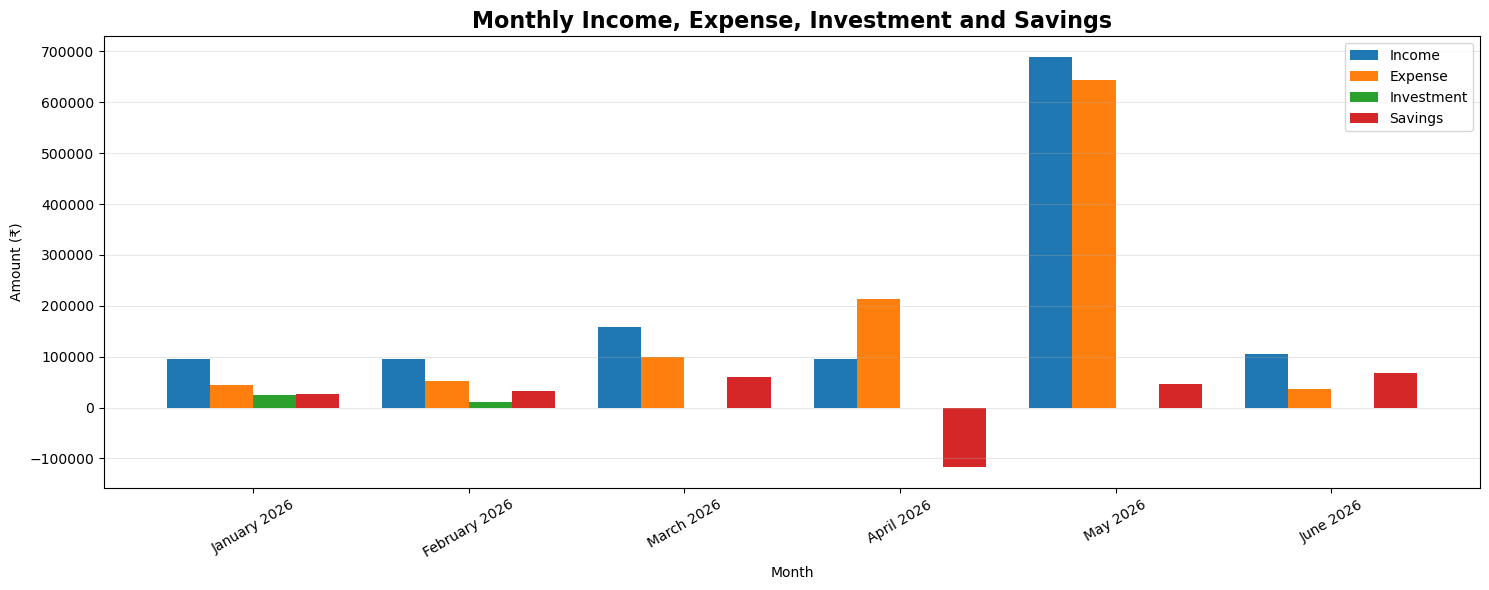

In [47]:
# =============================================================================
# MONTHLY SAVINGS ANALYSIS
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Income
# ----------------------------------------------------------

income = (
    df[df["Type"] == "CREDIT"]
    .groupby("Month")["Amount"]
    .sum()
)

# ----------------------------------------------------------
# Expense (excluding investments)
# ----------------------------------------------------------

expense = (
    df[
        (df["Type"] == "DEBIT") &
        (df["Investment"] == "None")
    ]
    .groupby("Month")["Amount"]
    .sum()
)

# ----------------------------------------------------------
# Investment
# ----------------------------------------------------------

investment = (
    df[df["Investment"] != "None"]
    .groupby("Month")["Amount"]
    .sum()
)

# ----------------------------------------------------------
# Combine
# ----------------------------------------------------------

summary = pd.concat(
    [income, expense, investment],
    axis=1
).fillna(0)

summary.columns = [
    "Income",
    "Expense",
    "Investment"
]

summary["Savings"] = (
    summary["Income"]
    - summary["Expense"]
    - summary["Investment"]
)

# ----------------------------------------------------------
# Month Order
# ----------------------------------------------------------

month_order = [
    "January 2026",
    "February 2026",
    "March 2026",
    "April 2026",
    "May 2026",
    "June 2026",
    "July 2026",
    "August 2026",
    "September 2026",
    "October 2026",
    "November 2026",
    "December 2026"
]

summary = summary.reindex(month_order).dropna(how="all")

print(summary)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(15,6))

x = np.arange(len(summary))
width = 0.2

plt.bar(x-1.5*width, summary["Income"], width, label="Income")
plt.bar(x-0.5*width, summary["Expense"], width, label="Expense")
plt.bar(x+0.5*width, summary["Investment"], width, label="Investment")
plt.bar(x+1.5*width, summary["Savings"], width, label="Savings")

plt.xticks(
    x,
    summary.index,
    rotation=30
)

plt.ylabel("Amount (₹)")
plt.xlabel("Month")

plt.title(
    "Monthly Income, Expense, Investment and Savings",
    fontsize=16,
    weight="bold"
)

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# =============================================================================
# SAVE FIGURE
# =============================================================================

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "06_Monthly_Savings_Analysis.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

Weekday
Monday        38547.07
Tuesday       18291.05
Wednesday    122866.58
Thursday     628543.40
Friday        77338.50
Saturday     143068.39
Sunday        60017.36
Name: Amount, dtype: float64


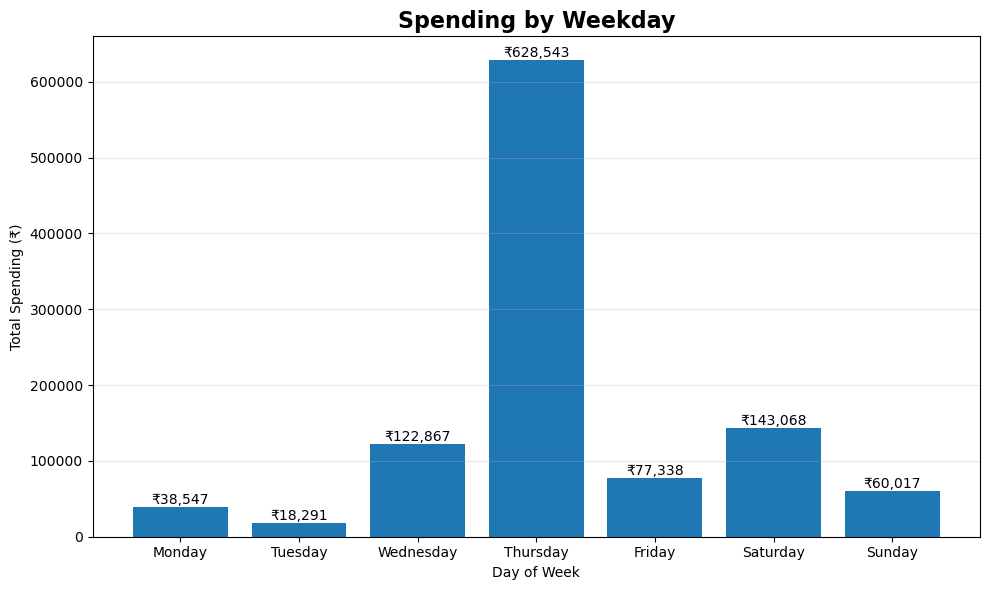

In [48]:
# =============================================================================
# SPENDING BY WEEKDAY
# =============================================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Filter actual expenses
# ----------------------------------------------------------

weekday_df = df[
    (df["Type"] == "DEBIT") &
    (df["Investment"] == "None")
].copy()

weekday_df = weekday_df[
    ~weekday_df["Category"].isin([
        "Salary",
        "Income"
    ])
]

# ----------------------------------------------------------
# Weekday
# ----------------------------------------------------------

weekday_df["Weekday"] = weekday_df["Date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_summary = (
    weekday_df
    .groupby("Weekday")["Amount"]
    .sum()
    .reindex(weekday_order)
)

print(weekday_summary)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

bars = plt.bar(
    weekday_summary.index,
    weekday_summary.values
)

# ----------------------------------------------------------
# Value labels
# ----------------------------------------------------------

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylabel("Total Spending (₹)")
plt.xlabel("Day of Week")

plt.title(
    "Spending by Weekday",
    fontsize=16,
    weight="bold"
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# =============================================================================
# SAVE FIGURE
# =============================================================================

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "07_Spending_By_Weekday.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

In [49]:
# =============================================================================
# ALL "OTHERS" TRANSACTIONS
# =============================================================================

others = (
    df[df["Category"] == "Others"]
    .sort_values("Amount", ascending=False)
)

print(f"Total Others Transactions : {len(others)}")

print(
    others[
        [
            "Date",
            "Merchant",
            "Description",
            "Amount",
            "Type",
            "Investment"
        ]
    ].to_string(index=False)
)

Total Others Transactions : 57
      Date Merchant                                          Description    Amount  Type Investment
2026-05-14   Others                               TO NIMAI CHARAN MAHATO 593000.00 DEBIT       None
2026-03-11   Others                                  TO TPW NIMAI MAHATO  54000.00 DEBIT       None
2026-04-04        M UPI/DR/609413934568/M/S.VARU/ICIC\n/varunphotostore/  51500.00 DEBIT       None
2026-04-08 Mutual F     UPI/DR/121272079093/MUTUAL F//groww.iccl1.\nbrk/  50000.00 DEBIT       None
2026-04-04 Khandala UPI/DR/121065281588/KHANDALA/UBIN\n/prakashkhandla1/  33000.00 DEBIT       None
2026-04-18 Groww In      UPI/DR/647415261125/GROWW IN//groww.\nbrkvalid/  30000.00 DEBIT       None
2026-02-13 Cred Clu  UPI/DR/118606145225/CRED Clu/UTIB/cred.\nclubaxisb/  14919.00 DEBIT       None
2026-02-08 Sunil Ku  UPI/DR/118350851851/Sunil Ku/IDFB\n/9990920089ptsb/  13000.00 DEBIT       None
2026-05-08 Sunil Ku  UPI/DR/649498704158/Sunil Ku/IDFB\n/9990920089pt

In [50]:
# =============================================================================
# TOP MERCHANTS IN "OTHERS"
# =============================================================================

merchant_summary = (
    others.groupby("Merchant")
    .agg(
        Transactions=("Merchant", "count"),
        Total_Amount=("Amount", "sum")
    )
    .sort_values(
        by="Total_Amount",
        ascending=False
    )
)

print(merchant_summary)

          Transactions  Total_Amount
Merchant                            
Others               6     653003.00
M                    1      51500.00
Mutual F             1      50000.00
Khandala             1      33000.00
Groww In             1      30000.00
Sunil Ku             4      25000.00
Sm639948             9      25000.00
Cred Clu             1      14919.00
Sbi Card             2      12140.00
Cred                 2       9144.00
Subhash              1       7200.00
Saikat M             3       6000.00
Harshit              1       3300.00
Rentomoj             4       3104.00
Sunrise              1       2000.00
Arun Che             1       2000.00
Jio Prep             3       1737.00
Stavan A             1       1600.00
Anisha S             1       1500.00
Wild Spl             1       1350.00
Shri Bal             1       1120.00
Ekta Ent             1        950.00
Seraj Ah             1        900.00
Skyard H             1        900.00
Carnatic             1        882.00
W

In [51]:
# =============================================================================
# SAVE OTHERS
# =============================================================================

others.to_excel(
    os.path.join(
        DATA_DIR,
        "Others_Transactions.xlsx"
    ),
    index=False
)

print("Saved successfully.")

Saved successfully.


Merchant
Carnatic       882.0
Seraj Ah       900.0
Skyard H       900.0
Ekta Ent       950.0
Shri Bal      1120.0
Wild Spl      1350.0
Anisha S      1500.0
Stavan A      1600.0
Jio Prep      1737.0
Arun Che      2000.0
Sunrise       2000.0
Rentomoj      3104.0
Harshit       3300.0
Saikat M      6000.0
Subhash       7200.0
Cred          9144.0
Sbi Card     12140.0
Cred Clu     14919.0
Sm639948     25000.0
Sunil Ku     25000.0
Groww In     30000.0
Khandala     33000.0
Mutual F     50000.0
M            51500.0
Others      653003.0
Name: Amount, dtype: float64


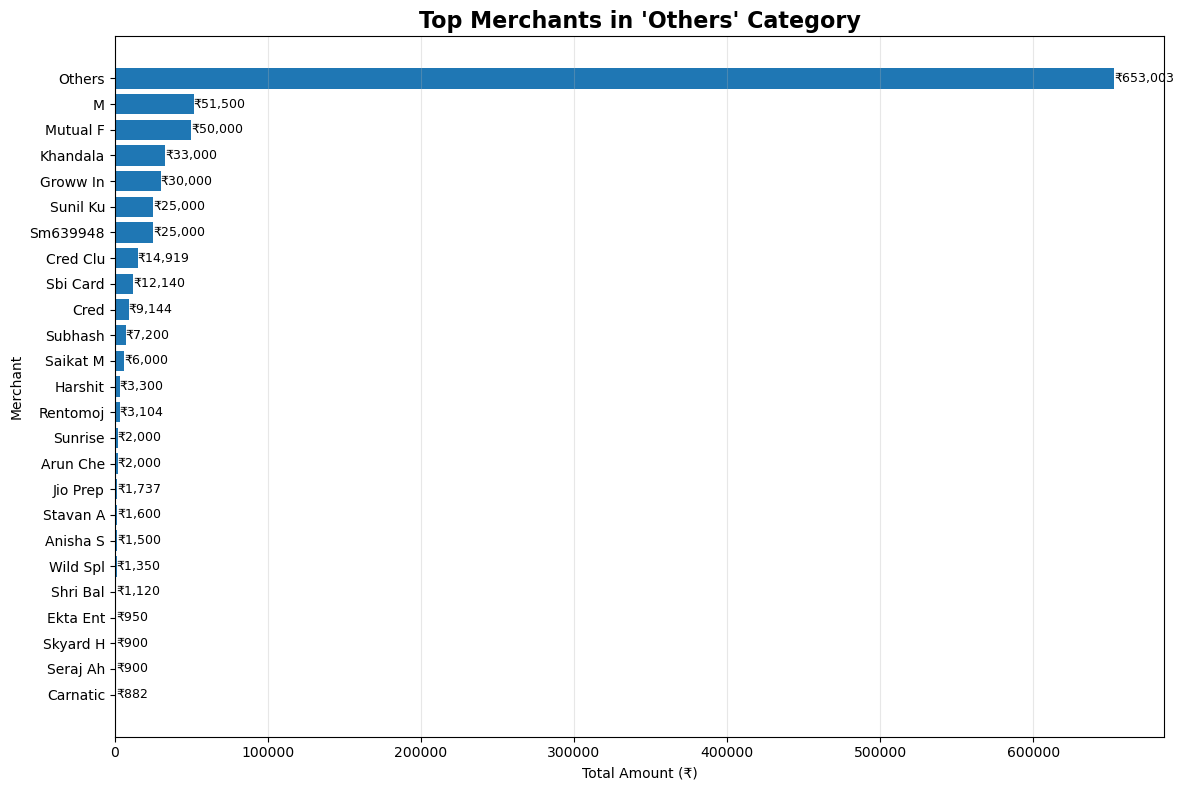

In [52]:
# =============================================================================
# TOP MERCHANTS IN "OTHERS"
# =============================================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Filter only Others (excluding investments)
# ----------------------------------------------------------

others_df = df[
    (df["Category"] == "Others") &
    (df["Investment"] == "None")
].copy()

# ----------------------------------------------------------
# Group by Merchant
# ----------------------------------------------------------

merchant_summary = (
    others_df
    .groupby("Merchant")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(25)
    .sort_values(ascending=True)
)

print(merchant_summary)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(12,8))

bars = plt.barh(
    merchant_summary.index,
    merchant_summary.values
)

# ----------------------------------------------------------
# Value Labels
# ----------------------------------------------------------

for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"₹{width:,.0f}",
        va="center",
        fontsize=9
    )

plt.xlabel("Total Amount (₹)")
plt.ylabel("Merchant")

plt.title(
    "Top Merchants in 'Others' Category",
    fontsize=16,
    weight="bold"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

# =============================================================================
# SAVE FIGURE
# =============================================================================

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "08_Top_Merchants_In_Others.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

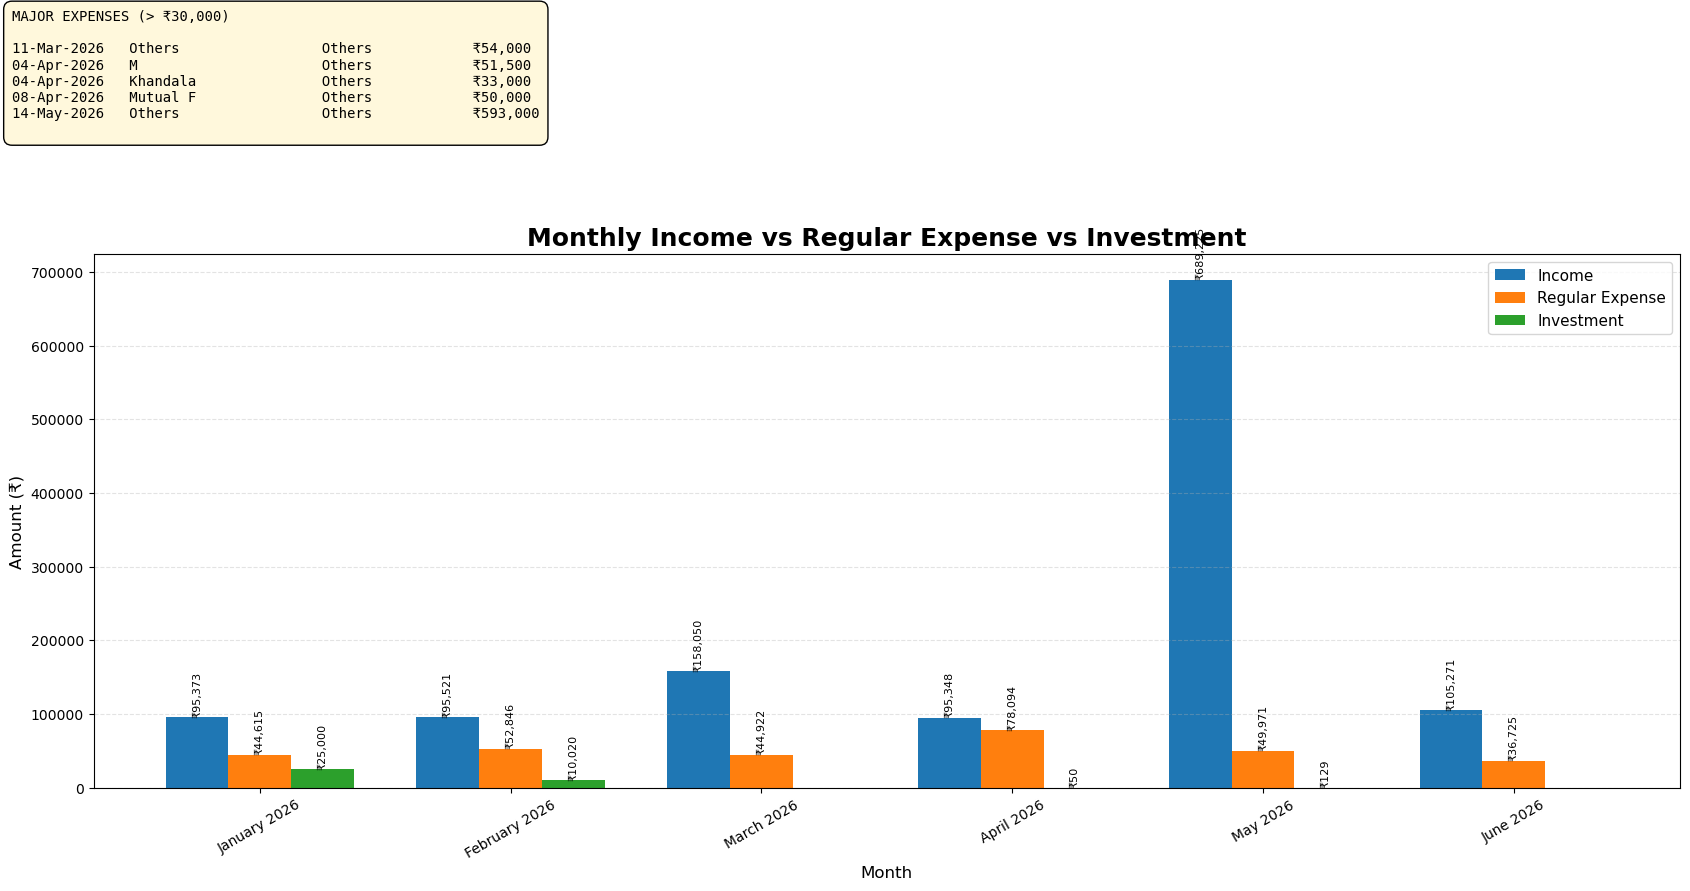

MONTHLY SUMMARY
                 Income   Expense  Investment
Month                                        
January 2026    95373.0  44615.28     25000.0
February 2026   95521.0  52845.58     10020.0
March 2026     158050.0  44922.24         0.0
April 2026      95348.0  78093.77        50.0
May 2026       689225.0  49970.83       129.0
June 2026      105270.8  36724.65         0.0


MAJOR EXPENSES (> ₹30,000)
      Date Merchant Category   Amount
2026-03-11   Others   Others  54000.0
2026-04-04        M   Others  51500.0
2026-04-04 Khandala   Others  33000.0
2026-04-08 Mutual F   Others  50000.0
2026-05-14   Others   Others 593000.0

Figure Saved To:
C:\Saikat\ME\Bank_Track\Figures\09_Monthly_Income_vs_RegularExpense_vs_Investment.png


In [54]:
# =============================================================================
# MONTHLY INCOME vs REGULAR EXPENSE vs INVESTMENT
# (Major Expenses > ₹30,000 are REMOVED from the Expense bars
#  and listed separately at the top.)
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# INCOME
# =============================================================================

income = (
    df[df["Type"].str.upper() == "CREDIT"]
    .groupby("Month")["Amount"]
    .sum()
)

# =============================================================================
# INVESTMENT
# =============================================================================

investment = (
    df[df["Investment"] != "None"]
    .groupby("Month")["Amount"]
    .sum()
)

# =============================================================================
# REGULAR EXPENSE
# (Exclude Investments and Major Expenses)
# =============================================================================

expense = (
    df[
        (df["Type"].str.upper() == "DEBIT") &
        (df["Investment"] == "None") &
        (df["Amount"] <= 30000)
    ]
    .groupby("Month")["Amount"]
    .sum()
)

# =============================================================================
# COMBINE
# =============================================================================

monthly = pd.concat(
    [income, expense, investment],
    axis=1
).fillna(0)

monthly.columns = [
    "Income",
    "Expense",
    "Investment"
]

# =============================================================================
# MONTH ORDER
# =============================================================================

month_order = [
    "January 2026",
    "February 2026",
    "March 2026",
    "April 2026",
    "May 2026",
    "June 2026",
    "July 2026",
    "August 2026",
    "September 2026",
    "October 2026",
    "November 2026",
    "December 2026"
]

monthly = monthly.reindex(month_order).dropna(how="all")

# =============================================================================
# MAJOR EXPENSES
# =============================================================================

major_expenses = (
    df[
        (df["Type"].str.upper() == "DEBIT") &
        (df["Investment"] == "None") &
        (df["Amount"] > 30000)
    ]
    .sort_values("Date")
)

major_text = ""

if len(major_expenses) == 0:

    major_text = "No Major Expenses (> ₹30,000)"

else:

    for _, row in major_expenses.iterrows():

        major_text += (
            f"{row['Date'].strftime('%d-%b-%Y')}   "
            f"{row['Merchant'][:20]:20s}   "
            f"{row['Category'][:15]:15s}   "
            f"₹{row['Amount']:,.0f}\n"
        )

# =============================================================================
# PLOT
# =============================================================================

plt.figure(figsize=(17,9))

x = np.arange(len(monthly))

width = 0.25

bars_income = plt.bar(
    x-width,
    monthly["Income"],
    width,
    label="Income"
)

bars_expense = plt.bar(
    x,
    monthly["Expense"],
    width,
    label="Regular Expense"
)

bars_investment = plt.bar(
    x+width,
    monthly["Investment"],
    width,
    label="Investment"
)

# =============================================================================
# VALUE LABELS
# =============================================================================

for bars in [bars_income, bars_expense, bars_investment]:

    for bar in bars:

        h = bar.get_height()

        if h > 0:

            plt.text(
                bar.get_x() + bar.get_width()/2,
                h,
                f"₹{h:,.0f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90
            )

# =============================================================================
# AXES
# =============================================================================

plt.xticks(
    x,
    monthly.index,
    rotation=30,
    fontsize=10
)

plt.ylabel(
    "Amount (₹)",
    fontsize=12
)

plt.xlabel(
    "Month",
    fontsize=12
)

plt.title(
    "Monthly Income vs Regular Expense vs Investment",
    fontsize=18,
    weight="bold"
)

plt.legend(fontsize=11)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

# =============================================================================
# MAJOR EXPENSE BOX
# =============================================================================

plt.figtext(
    0.01,
    0.985,
    "MAJOR EXPENSES (> ₹30,000)\n\n" + major_text,
    ha="left",
    va="top",
    fontsize=10,
    family="monospace",
    bbox=dict(
        facecolor="#FFF8DC",
        edgecolor="black",
        boxstyle="round,pad=0.6"
    )
)

# =============================================================================
# LAYOUT
# =============================================================================

plt.tight_layout(rect=[0,0,1,0.76])

# =============================================================================
# SAVE FIGURE
# =============================================================================

save_path = os.path.join(
    FIGURE_DIR,
    "09_Monthly_Income_vs_RegularExpense_vs_Investment.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

# =============================================================================
# PRINT SUMMARY
# =============================================================================

print("="*80)
print("MONTHLY SUMMARY")
print("="*80)

print(monthly)

print("\n")

print("="*80)
print("MAJOR EXPENSES (> ₹30,000)")
print("="*80)

if len(major_expenses):

    print(
        major_expenses[
            [
                "Date",
                "Merchant",
                "Category",
                "Amount"
            ]
        ].to_string(index=False)
    )

else:

    print("No Major Expenses Found.")

print("\nFigure Saved To:")
print(save_path)